# Una huella de hace 4.500 millones de años, escondida en una lava de hoy

Un volcán submarino en las Comoras escupió lava con una pista química imposible de fabricar hoy. La única forma de crearla fue en los primeros 100 millones de años de la Tierra. Veamos por qué el número **+3,2 partes por millón** obliga a mirar tan atrás.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Hadean bridgmanite in the source of a present-day ocean island* — Nature (2026)
**DOI:** [10.1038/s41586-026-10719-w](https://doi.org/10.1038/s41586-026-10719-w)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-01-bridgmanita-hadeana-manto/notebook.ipynb)

**Video:** [Pendiente]

## ¿Qué midieron y por qué importa?

El manto terrestre no es una sopa homogénea: guarda parches químicos de distintas edades. La pregunta difícil es **cuándo** se formaron esos parches. El equipo midió con altísima precisión el neodimio (Nd) en 21 lavas de dos volcanes vecinos del archipiélago de las Comoras: **Fani Maore** (submarino, el que hizo temblar Mayotte en 2018) y **Mayotte** mismo.

La clave está en un isótopo raro, el ¹⁴²Nd. Se fabrica cuando decae el ¹⁴⁶Sm — un reloj radiactivo que se agotó por completo hace unos 4.500 millones de años. Si una lava de hoy trae exceso de ¹⁴²Nd, ese exceso **tuvo** que crearse cuando el reloj todavía andaba: en el Hadeano, la infancia del planeta.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ESTANDAR_CERO = 0.0        # El estándar JNdi-1 define el "cero" del anómalo mu142Nd
VENTANA_MYR = 100          # Ventana en que pudo formarse la señal (primeros Myr)
COLOR_ANOMALIA = '#DC2626' # Rojo CaM — Fani Maore, la anomalía
COLOR_VECINO = '#2563EB'   # Azul CaM — Mayotte, el volcán vecino
COLOR_ESTANDAR = '#BBBBBB' # Gris — el estándar de referencia
COLOR_UMBRAL = '#D97706'   # Ámbar — la línea del cero
FUENTE = 'Fuente: Israel et al. (2026), Nature | Datos: EarthChem IEDA/114197'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo editorial CaM (local -> fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de datos
todos = pd.read_csv('datos/mu142nd_todos.csv')
part  = pd.read_csv('datos/particion_brg_melt.csv')
comp  = pd.read_csv('datos/bridgmanita_composicion.csv')

fani = todos[todos.grupo == 'Fani Maore']['mu142Nd_ppm']
mayo = todos[todos.grupo == 'Mayotte']['mu142Nd_ppm']
jndi = todos[todos.grupo == 'JNdi-1']['mu142Nd_ppm']

print(f"Lavas y estándares medidos: {len(todos)} análisis")
print(f"  Fani Maore: n={len(fani):2d} | media {fani.mean():+.2f} ppm | mediana {fani.median():+.2f}")
print(f"  Mayotte:    n={len(mayo):2d} | media {mayo.mean():+.2f} ppm | mediana {mayo.median():+.2f}")
print(f"  JNdi-1:     n={len(jndi):2d} | media {jndi.mean():+.2f} ppm (el cero por construcción)")

Lavas y estándares medidos: 44 análisis
  Fani Maore: n=13 | media +3.17 ppm | mediana +3.05
  Mayotte:    n= 8 | media +1.17 ppm | mediana +0.81
  JNdi-1:     n=23 | media -0.00 ppm (el cero por construcción)


## Aquí está.

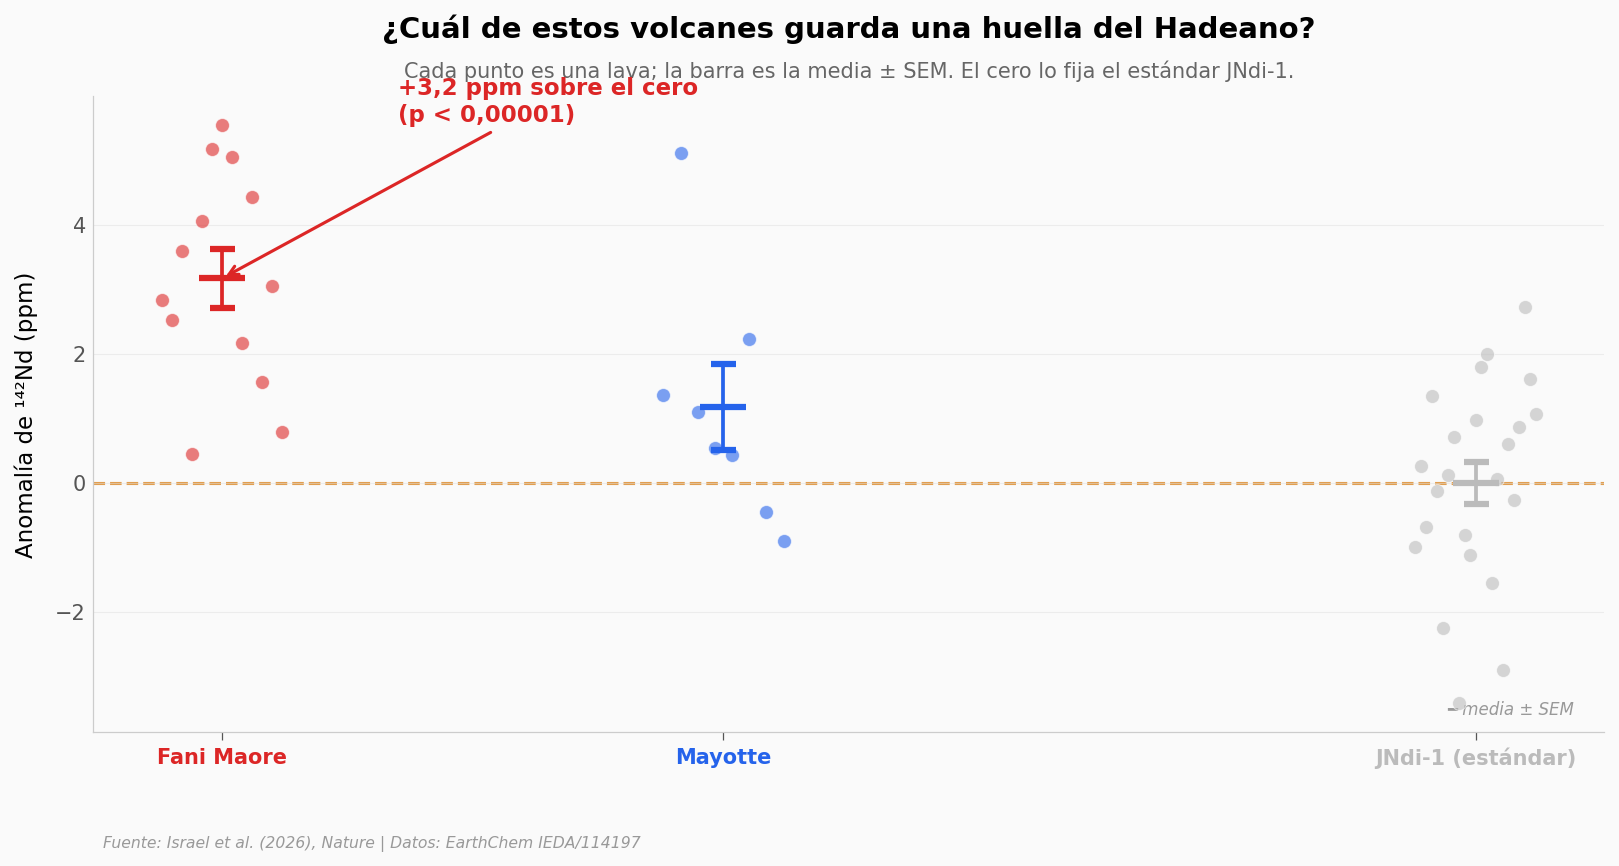

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

np.random.seed(42)  # jitter reproducible
grupos = [
    ('Fani Maore', fani, COLOR_ANOMALIA),
    ('Mayotte',    mayo, COLOR_VECINO),
    ('JNdi-1 (estándar)', jndi, COLOR_ESTANDAR),
]
positions = [0, 1, 2.5]  # separar el estándar del par de volcanes

# Línea del cero (el estándar)
ax.axhline(y=ESTANDAR_CERO, color=COLOR_UMBRAL, linewidth=1.5, linestyle='--', alpha=0.7, zorder=1)

for pos, (nombre, vals, color) in zip(positions, grupos):
    n = len(vals)
    x_strip = np.linspace(pos - 0.12, pos + 0.12, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=45, alpha=0.6,
               edgecolors='white', linewidths=0.5, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(pos, mean, yerr=sem, fmt='_', color=color,
                markersize=22, markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)

ax.set_xticks(positions)
ax.set_xticklabels([g[0] for g in grupos], fontsize=10, fontweight='bold')
for tick, (_, _, color) in zip(ax.get_xticklabels(), grupos):
    tick.set_color(color)

ax.set_ylabel('Anomalía de ¹⁴²Nd (ppm)', fontsize=11)
ax.set_title('¿Cuál de estos volcanes guarda una huella del Hadeano?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto es una lava; la barra es la media ± SEM. El cero lo fija el estándar JNdi-1.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.annotate('+3,2 ppm sobre el cero\n(p < 0,00001)', xy=(0, fani.mean()),
            xytext=(0.35, 5.6), fontsize=11, fontweight='bold', color=COLOR_ANOMALIA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ANOMALIA, lw=1.5))
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_grupos.png', dpi=200, bbox_inches='tight')
plt.show()

Lo que salta a la vista: solo Fani Maore se despega del cero. Su media queda en **+3,2 ppm**, con casi todas sus lavas por encima de la línea del estándar. Mayotte, a pocos kilómetros, ronda **+1,2 ppm** — y sus puntos se reparten a ambos lados del cero.

Esa diferencia no es de a ojo. Un test de Welch da p = 0,028 entre Fani Maore y Mayotte, y p < 0,00001 entre Fani Maore y el estándar. Mayotte, en cambio, no se distingue del estándar (p = 0,14). Dos volcanes casi tocándose, y solo uno trae la firma.

## ¿Por qué esa firma apunta a un mineral concreto?

Una anomalía de ¹⁴²Nd necesita que, muy temprano, algo haya subido la razón Sm/Nd de ese pedazo de manto. El sospechoso es la **bridgmanita** (brg): el mineral más abundante del manto profundo, que cristaliza a altísima presión. Los autores midieron en laboratorio (celda de yunques de diamante, a 53 y 97 GPa) cuánto Sm y cuánto Nd atrapa la bridgmanita al formarse.

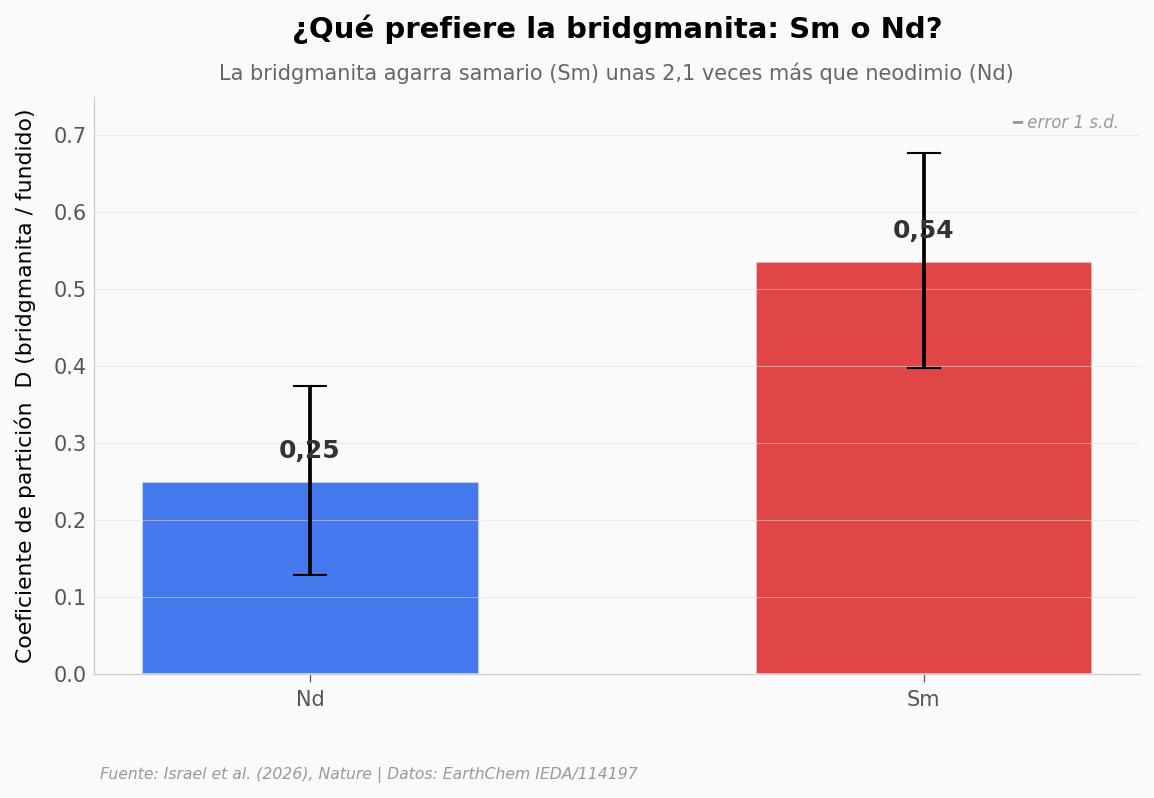

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

elem = part['elemento'].tolist()
D = part['D_brg_melt'].values
err = part['err_1sd'].values
colores = [COLOR_VECINO, COLOR_ANOMALIA]  # Nd azul, Sm rojo

barras = ax.bar(elem, D, yerr=err, color=colores, alpha=0.85,
                width=0.55, capsize=8, edgecolor='white', linewidth=1.2)
for x, d in zip(elem, D):
    ax.text(x, d + 0.03, f'{d:.2f}'.replace('.', ','), ha='center',
            fontsize=12, fontweight='bold', color='#333333')

ratio = D[1] / D[0]
ax.set_ylabel('Coeficiente de partición  D (bridgmanita / fundido)', fontsize=10.5)
ax.set_title('¿Qué prefiere la bridgmanita: Sm o Nd?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'La bridgmanita agarra samario (Sm) unas {ratio:.1f}'.replace('.', ',') + ' veces más que neodimio (Nd)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 0.75)
ax.text(0.98, 0.97, '━ error 1 s.d.', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='top', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/particion_D.png', dpi=200, bbox_inches='tight')
plt.show()

Ese detalle de laboratorio tiene una consecuencia enorme. Si la bridgmanita se queda con más Sm que Nd, el pedazo de manto donde cristaliza **duplica su razón Sm/Nd**. Y como el Sm alimenta al ¹⁴²Nd por el reloj del ¹⁴⁶Sm, ese pedazo se convierte en una fábrica de la anomalía — pero solo si el reloj todavía andaba.

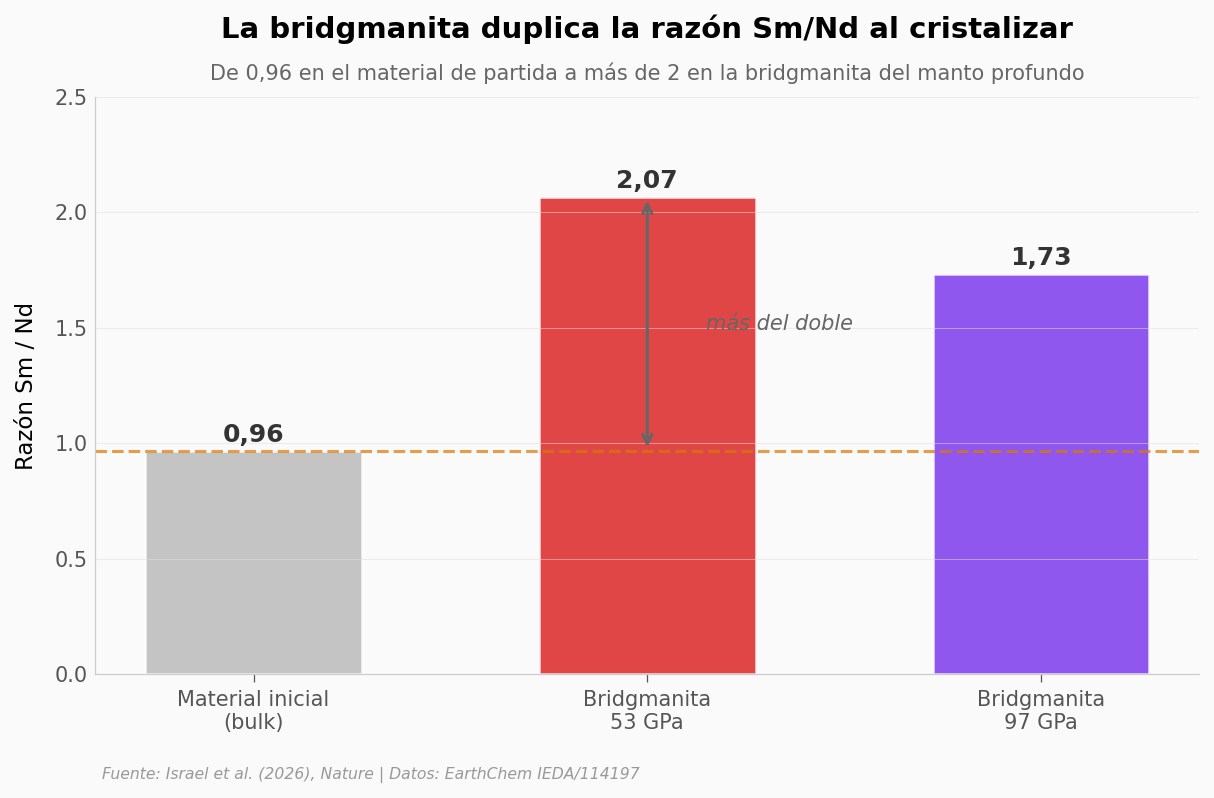

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 5))

comp = comp.copy()
comp['SmNd'] = comp['SmO1.5'] / comp['NdO1.5']
etiquetas = ['Material inicial\n(bulk)', 'Bridgmanita\n53 GPa', 'Bridgmanita\n97 GPa']
valores = comp['SmNd'].values
colores = [COLOR_ESTANDAR, COLOR_ANOMALIA, '#7C3AED']

barras = ax.bar(etiquetas, valores, color=colores, alpha=0.85,
                width=0.55, edgecolor='white', linewidth=1.2)
for x, v in zip(range(len(valores)), valores):
    ax.text(x, v + 0.04, f'{v:.2f}'.replace('.', ','), ha='center',
            fontsize=12, fontweight='bold', color='#333333')

# Línea de referencia: el bulk de partida
ax.axhline(y=valores[0], color=COLOR_UMBRAL, linewidth=1.5, linestyle='--', alpha=0.7)
ax.annotate('', xy=(1, valores[1]), xytext=(1, valores[0]),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(1.15, (valores[0] + valores[1]) / 2, 'más del doble',
        fontsize=10, color='#666666', va='center', style='italic')

ax.set_ylabel('Razón Sm / Nd', fontsize=11)
ax.set_title('La bridgmanita duplica la razón Sm/Nd al cristalizar',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'De 0,96 en el material de partida a más de 2 en la bridgmanita del manto profundo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 2.5)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sm_nd_ratio.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan lejos del montón está esa lava?

Juntemos las 44 mediciones — las 21 lavas y los 23 estándares — en un solo histograma.

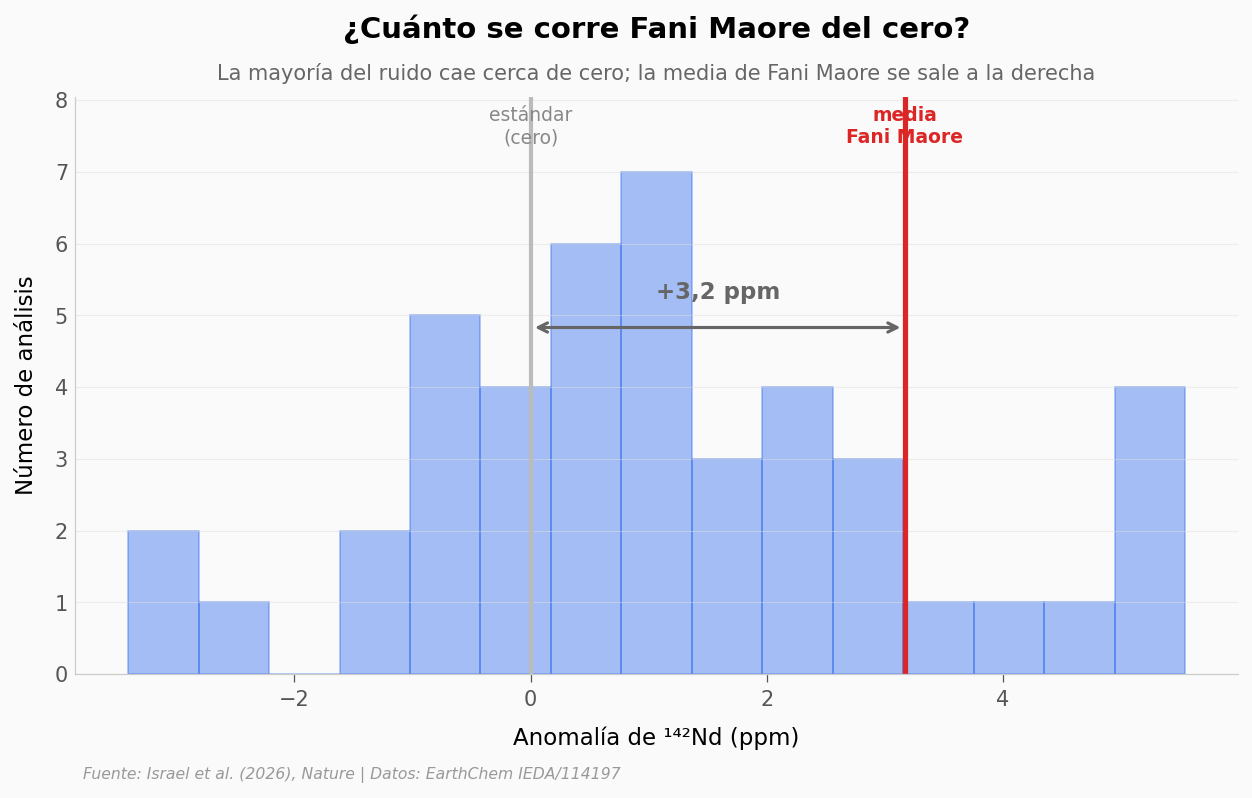

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

data = todos['mu142Nd_ppm']
n, bins, patches = ax.hist(data, bins=15, color=COLOR_VECINO, alpha=0.4,
                           edgecolor=COLOR_VECINO, linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

media_fani = fani.mean()
ax.axvline(x=ESTANDAR_CERO, color=COLOR_ESTANDAR, linewidth=2.0)
ax.axvline(x=media_fani, color=COLOR_ANOMALIA, linewidth=2.5)
ax.annotate('', xy=(media_fani, y_max * 0.6), xytext=(ESTANDAR_CERO, y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((media_fani + ESTANDAR_CERO) / 2, y_max * 0.65, '+3,2 ppm',
        ha='center', fontsize=11, fontweight='bold', color='#666666')

ax.text(ESTANDAR_CERO, y_max * 0.92, 'estándar\n(cero)', ha='center',
        fontsize=9, color='#888888')
ax.text(media_fani, y_max * 0.92, 'media\nFani Maore', ha='center',
        fontsize=9, fontweight='bold', color=COLOR_ANOMALIA)

ax.set_xlabel('Anomalía de ¹⁴²Nd (ppm)', fontsize=11)
ax.set_ylabel('Número de análisis', fontsize=11)
ax.set_title('¿Cuánto se corre Fani Maore del cero?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'La mayoría del ruido cae cerca de cero; la media de Fani Maore se sale a la derecha',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Fani Maore tiene una anomalía positiva de ¹⁴²Nd (+3,2 ppm) | ✅ | Media +3,17 ppm, n=13; distinta del estándar con p < 0,00001, Cohen's d = 1,98 (Welch) |
| Fani Maore se distingue de su vecino Mayotte | ✅ | Δ = 2,0 ppm; Welch p = 0,028; Cohen's d = 1,15 (efecto grande) |
| Mayotte NO muestra la anomalía robusta | ✅ | Media +1,17 ppm, pero no se distingue del estándar (p = 0,14) |
| La bridgmanita atrapa Sm ~2× más que Nd | ✅ | D_Sm/D_Nd = 2,1 medido en celda de diamante (53 y 97 GPa) |
| La razón Sm/Nd se duplica en la bridgmanita | ✅ | 0,96 (bulk) → 2,07 (Brg 53 GPa), calculado desde las fracciones molares |
| La señal exige material formado en los primeros 100 Myr | ⚠️ | Inferencia fuerte: solo el ¹⁴⁶Sm (extinto) puede fabricar ¹⁴²Nd, pero el origen exacto se deduce, no se observa |
| Ese material es bridgmanita de un océano de magma | ⚠️ | Es la hipótesis de los autores ("suggest"), la más consistente con la partición — no una prueba directa |

> **Limitaciones:** las anomalías de ¹⁴²Nd son de pocas partes por millón, cerca del límite de detección; los errores por muestra (2 s.e.) llegan a ser grandes en análisis individuales. La atribución a bridgmanita de un océano de magma descansa en coeficientes de partición de experimentos de laboratorio, con su propia incertidumbre (±0,12–0,14). Que la bridgmanita hadeana esté "más extendida" en el manto es una pregunta abierta, no un resultado medido.

## Ahora tú

1. **¿Cambia la conclusión si sacas la muestra más extrema de Fani Maore?** Quita el valor máximo y recalcula la media y el test de Welch. Pista: `fani.nlargest(1).index` para ubicarla.

2. **¿Cuánto pesa el error de medición?** Cada lava trae su propio `err_2se_ppm`. Grafica la anomalía con barras de error por muestra y mira cuántas siguen sobre el cero. Pista: `ax.errorbar(range(len(fani)), fani, yerr=...)`.

3. **¿Qué tan sensible es el reloj?** Si la bridgmanita solo duplicara a medias la razón Sm/Nd (digamos 1,5 en vez de 2,07), ¿seguiría siendo llamativa frente al bulk de 0,96? Cambia el valor y compáralo.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Sigue siendo significativa Fani Maore si quitamos su lava más extrema?
fani_recortado = fani.drop(fani.idxmax())

t, p = stats.ttest_ind(fani_recortado, jndi, equal_var=False)
print(f"Fani Maore SIN su valor máximo:")
print(f"  n = {len(fani_recortado)} | media {fani_recortado.mean():+.2f} ppm")
print(f"  vs estándar JNdi-1 -> Welch p = {p:.2e}")
print(f"  {'Sigue siendo distinta del cero' if p < 0.05 else 'Ya no se distingue del cero'}")

Fani Maore SIN su valor máximo:
  n = 12 | media +2.97 ppm
  vs estándar JNdi-1 -> Welch p = 2.19e-05
  Sigue siendo distinta del cero


## Créditos

**Paper:** *Hadean bridgmanite in the source of a present-day ocean island* — Nature (2026)
DOI: [10.1038/s41586-026-10719-w](https://doi.org/10.1038/s41586-026-10719-w)

**Datos:** EarthChem (IEDA) — [doi.org/10.60520/IEDA/114197](https://doi.org/10.60520/IEDA/114197), espejo de los Supplementary Data del paper.

**Licencia datos:** CC-BY (EarthChem / Springer Supplementary).

**Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)

---

## Fuentes

**Paper**: [Hadean bridgmanite in the source of a present-day ocean island](https://doi.org/10.1038/s41586-026-10719-w)  
*Nature, 2026-07-01*

**Datos**: [Nd isotope geochemical data for Fani Maore and Mayotte lavas (Israel et al. 2026)](https://doi.org/10.60520/IEDA/114197)  
*EarthChem (IEDA)*

*14 afirmaciones verificadas contra estas fuentes*